In [24]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from base.read_matrix import MatrixDataReader
from base.common import *
from base.impedance_analysis import *

import numpy as np
import matplotlib.pyplot as plt

fsave_set_save(False)
fsave_set_dpi(300)
fsave_set_pad_inches(0.2)
%config InlineBackend.figure_format='svg'

In [25]:
md = MatrixDataReader(['../../run/EC.txt'])
md.read_matrices()

File: ../../run/EC.txt
Rows: 15
Cols: 1107000
Size: 348705000 bytes
Time: 3.99 seconds



In [26]:
# start_idx = 1476000

time = md.data[0][0]# [start_idx:]
Vccp = md.data[0][1]# [start_idx:]
cap = md.data[0][2]# [start_idx:]
charge = md.data[0][3]# [start_idx:]
Qm1 = md.data[0][4]# [start_idx:]
Qm2 = md.data[0][5]# [start_idx:]
Im2 = md.data[0][6]# [start_idx:]
Qei = md.data[0][7]# [start_idx:]
Istray = md.data[0][8]# [start_idx:]
Qe = md.data[0][9]# [start_idx:]
Vs = md.data[0][10]# [start_idx:]
Iei = md.data[0][11]# [start_idx:]
Vei = md.data[0][12]# [start_idx:]
Iconv = md.data[0][13]# [start_idx:]

In [27]:
print (len(Qm1))
Uload = (Qm1 - Qm2) / (1.5e-10)
Iload = (Vs - Uload) / 50
Iccp = Im2 - Istray
print (len(Uload))

1107000
1107000


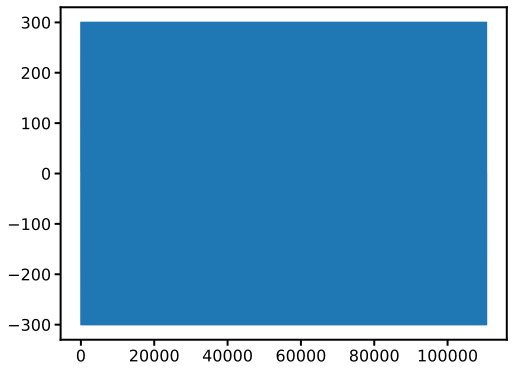

In [28]:
font, size = curvestyle()
plt.plot(time/1e-9, Vs)
fs('./Us')

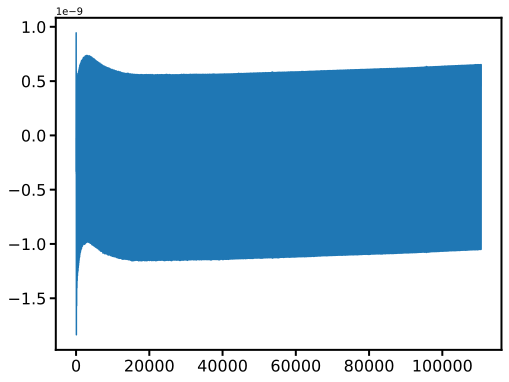

In [29]:
font, size = curvestyle()
plt.plot(time/1e-9, charge)
fs('./charge')

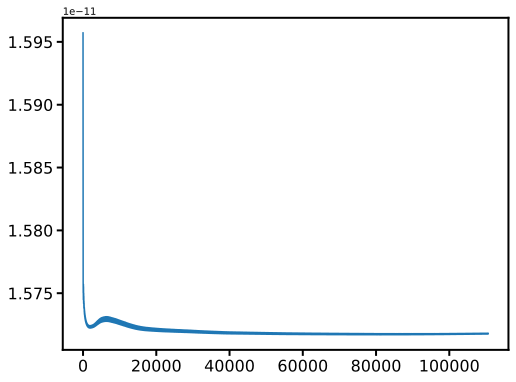

In [30]:
font, size = curvestyle()
plt.plot(time/1e-9, cap)
fs('./cap')

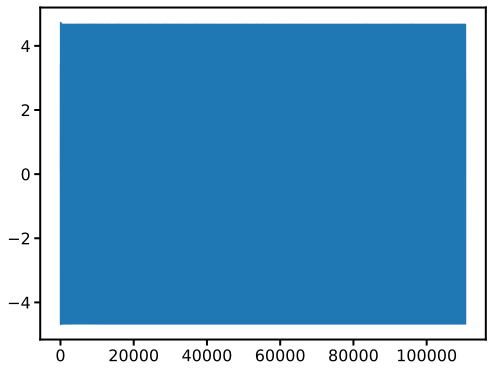

In [31]:
font, size = curvestyle()
plt.plot(time/1e-9, Iload)
fs('./Iload')

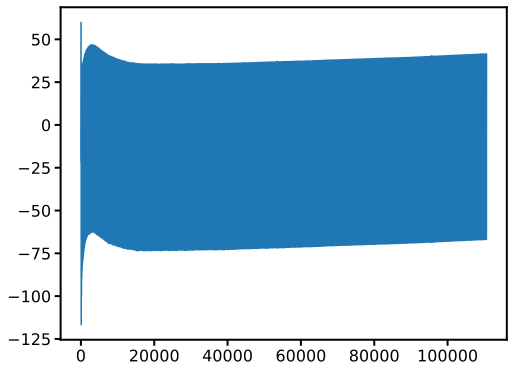

In [32]:
font, size = curvestyle()
plt.plot(time/1e-9, Vccp)
fs('./Uccp')

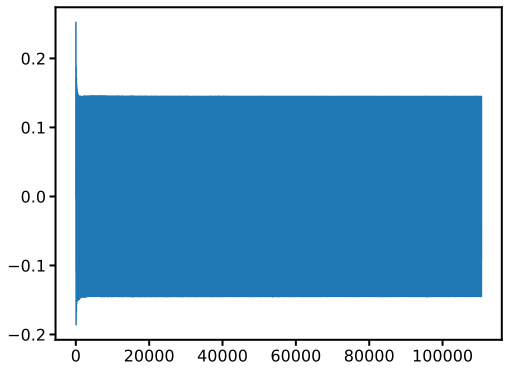

In [33]:
font, size = curvestyle()
plt.plot(time/1e-9, Iccp)
fs('./Iccp')

In [34]:
dt = time[1] - time[0]
f = 27.12e6
istart = 920000
iend = istart + int(500 / 27.12e6 / dt + 0.5)
istart, iend

(920000, 1104500)

In [35]:
zl = get_equivalent_impedance(Uload[istart:iend], Iload[istart:iend], dt, f)
zl

(0.0009275133443111756-40.33661233549112j)

In [36]:
gamma = (zl - 50) / (zl + 50)
gamma

(-0.2115166318805253-0.9773514042339029j)

In [37]:
np.abs(gamma)

0.999977526207496

In [38]:
Zccp = get_equivalent_impedance(Vccp[istart:iend], Iccp[istart:iend], dt, f)
Zccp

(0.6058716955633566-373.54755543822046j)

In [39]:
Rccp = Zccp.real
Cccp = -1 / (2 * np.pi * f * Zccp.imag)
Rccp, Cccp

(0.6058716955633566, 1.5710302513890372e-11)

In [40]:
import math

Rm = 0.5
Rc = Rccp
Cc = Cccp
Rs = 50
Lm = 1e-5

Cm1_New=math.sqrt((Rs-Rm-Rc)/(Rm+Rc))/(2*math.pi*f*Rs)
   
# if(((1.0d0)/(-((Rs-Rm-Rc)/(Rs*Cm1_New))-(1.0d0/Cc)+((2*PI*f)*(2*PI*f)*Lm)))>0.d0) then
Cm2_New=1/(-((Rs-Rm-Rc)/(Rs*Cm1_New))-(1/Cc)+((2*math.pi*f)*(2*math.pi*f)*Lm))
# else
    # Lm_New=((1.0d0/Cm2)+((Rs-Rm-Rc)/(Rs*Cm1_New))+(1.0d0/Cc))/((2*PI*f)*(2*PI*f))  !Cm2不为正数时更新Cm1和L
# end if

print(Cm1_New, Cm2_New)

7.804344373012038e-10 4.435454174422733e-12


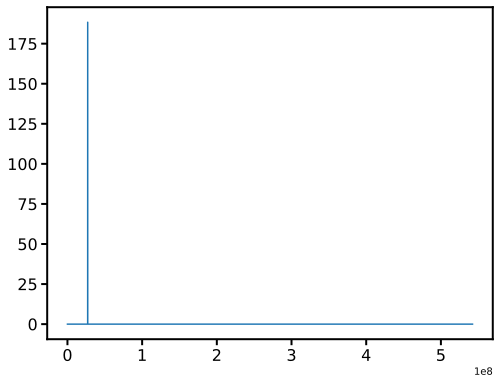

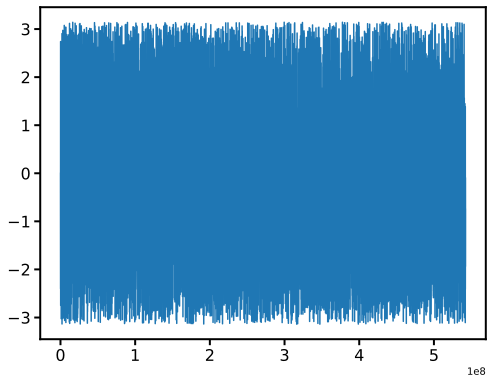

In [41]:
freq, amp_u, pha_u = get_fftw(Uload[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Uload_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Uload_fft_pha')

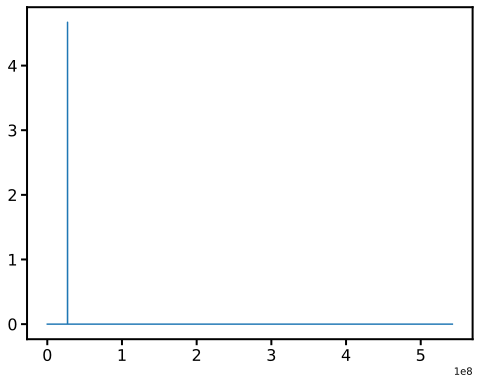

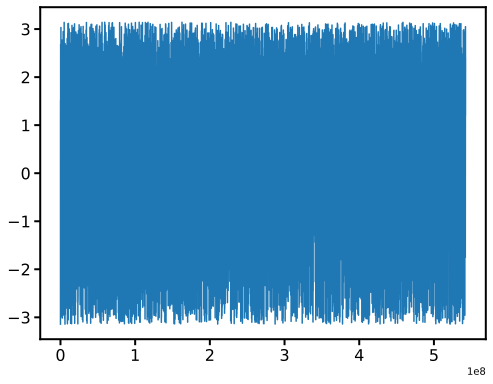

In [42]:
freq, amp_u, pha_u = get_fftw(Iload[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Iload_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Iload_fft_pha')

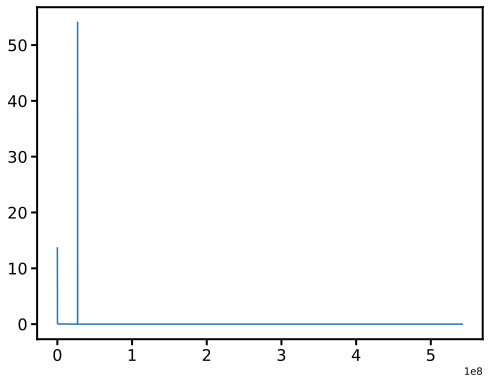

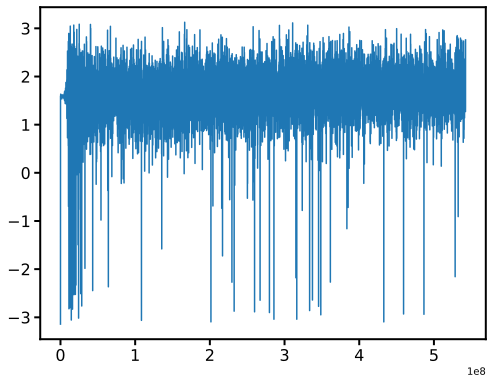

In [43]:
freq, amp_u, pha_u = get_fftw(Vccp[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Uccp_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Uccp_fft_pha')

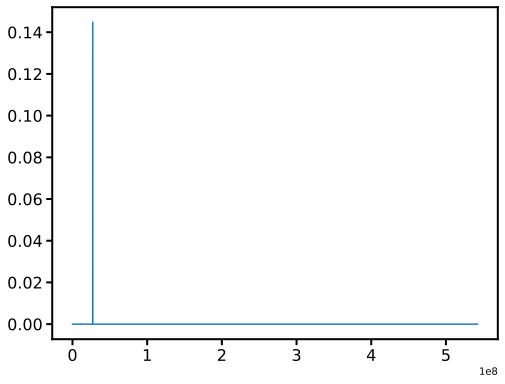

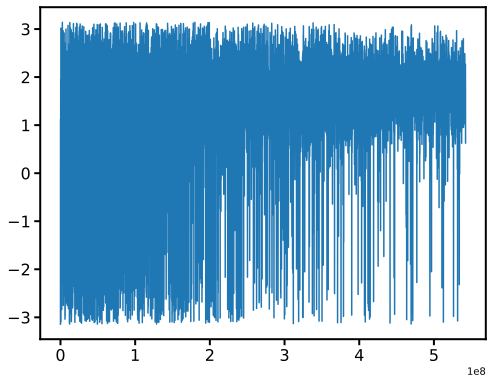

In [44]:
freq, amp_u, pha_u = get_fftw(Iccp[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Iccp_fft_pha')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Iccp_fft_pha')

In [45]:
power_all = get_base_power(Vs[istart:iend], Iload[istart:iend], dt, f)
power_load = get_base_power(Uload[istart:iend], Iload[istart:iend], dt, f)
power_stray = get_base_power(Vccp[istart:iend], Im2[istart:iend], dt, f)
power_ccp = get_base_power(Vccp[istart:iend], Iccp[istart:iend], dt, f)

In [46]:
power_all, power_all - power_load, power_load - power_stray, power_stray - power_ccp, power_ccp

(700.4186355490036,
 260.7757711701597,
 435.7416009237416,
 0.0,
 3.901263455102332)